# 8c - Signer-Aware Split for 7c Frames Dataset

This notebook creates train/val/test splits from the frame-level dataset generated in 7c.

Design goals:
- split target close to 80/10/10 (with configurable tolerance),
- minimize or remove signer leakage across splits,
- keep class coverage in every split,
- report diagnostics and plots for audit.

Optimization strategy:
1. many greedy starts with different seeds,
2. local improvements by moving signer groups,
3. local random swap refinement,
4. choose best solution by objective + constraints.

In [1]:
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 240)
plt.style.use('ggplot')

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_frames_normalized_from_raw.csv'
OUTPUT_SPLIT_CSV = PROJECT_ROOT / 'merged_datasets' / 'split8c_frames_signer_disjoint.csv'
OUTPUT_STATS_CSV = PROJECT_ROOT / 'merged_datasets' / 'split8c_frames_stats.csv'
OUTPUT_SIGNER_MAP_CSV = PROJECT_ROOT / 'merged_datasets' / 'split8c_signer_map.csv'
OUTPUT_LABEL_COUNTS_CSV = PROJECT_ROOT / 'merged_datasets' / 'split8c_label_split_counts.csv'
OUTPUT_VIDEO_LEAK_CSV = PROJECT_ROOT / 'merged_datasets' / 'split8c_video_leak_examples.csv'

LABEL_COL = 'label'
SIGNER_COL = 'signer_id'
VIDEO_COL = 'video_path'
SPLIT_COL = 'split'

SPLITS = ['train', 'val', 'test']
TARGET_RATIOS = np.array([0.80, 0.10, 0.10], dtype=float)
TARGET_SER = pd.Series(TARGET_RATIOS, index=SPLITS)
GLOBAL_RATIO_TOL = 0.02

N_TRIALS = 100
BASE_SEED = 42
LOCAL_MOVE_PASSES = 4
LOCAL_SWAP_PASSES = 2
SWAP_PAIR_TRIALS_PER_PASS = 2500

FILTER_ONLY_OK = True
ENFORCE_VIDEO_PATH_DISJOINT = False
HARD_REQUIRE_CLASS_COVERAGE = True
HARD_REQUIRE_VIDEO_PATH_DISJOINT = False

if not INPUT_CSV.exists():
    raise FileNotFoundError(f'Input CSV not found: {INPUT_CSV}')

print('INPUT_CSV:', INPUT_CSV)
print('OUTPUT_SPLIT_CSV:', OUTPUT_SPLIT_CSV)
print('SPLITS:', SPLITS)
print('TARGET_RATIOS:', TARGET_RATIOS)
print('GLOBAL_RATIO_TOL:', GLOBAL_RATIO_TOL)
print('N_TRIALS:', N_TRIALS)
print('ENFORCE_VIDEO_PATH_DISJOINT:', ENFORCE_VIDEO_PATH_DISJOINT)
print('HARD_REQUIRE_VIDEO_PATH_DISJOINT:', HARD_REQUIRE_VIDEO_PATH_DISJOINT)

INPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_frames_normalized_from_raw.csv
OUTPUT_SPLIT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\split8c_frames_signer_disjoint.csv
SPLITS: ['train', 'val', 'test']
TARGET_RATIOS: [0.8 0.1 0.1]
GLOBAL_RATIO_TOL: 0.02
N_TRIALS: 100
ENFORCE_VIDEO_PATH_DISJOINT: False
HARD_REQUIRE_VIDEO_PATH_DISJOINT: False


In [3]:
def prepare_input_df(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = [LABEL_COL, SIGNER_COL, VIDEO_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    out = df.copy()
    if FILTER_ONLY_OK and 'process_status' in out.columns:
        out = out[out['process_status'] == 'ok'].copy()

    out = out.dropna(subset=[LABEL_COL, SIGNER_COL, VIDEO_COL]).copy()
    out[LABEL_COL] = out[LABEL_COL].astype(str)
    out[SIGNER_COL] = out[SIGNER_COL].astype(str)
    out[VIDEO_COL] = out[VIDEO_COL].astype(str)
    out = out.reset_index(drop=True)
    return out


def build_group_id_series(
    df: pd.DataFrame,
    signer_col: str,
    video_col: str,
    enforce_video_disjoint: bool,
) -> tuple[pd.Series, dict[str, str]]:
    signer_series = df[signer_col].astype(str)
    if not enforce_video_disjoint:
        signer_to_group = {s: s for s in signer_series.unique()}
        return signer_series.copy(), signer_to_group

    signers = signer_series.unique().tolist()
    signer_to_idx = {s: i for i, s in enumerate(signers)}
    parent = list(range(len(signers)))
    rank = [0] * len(signers)

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra = find(a)
        rb = find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[rb] < rank[ra]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    for _, g in df.groupby(video_col, sort=False):
        svals = g[signer_col].astype(str).unique().tolist()
        if len(svals) <= 1:
            continue
        root_idx = signer_to_idx[svals[0]]
        for s in svals[1:]:
            union(root_idx, signer_to_idx[s])

    root_to_group = {}
    signer_to_group = {}
    for s in signers:
        root = find(signer_to_idx[s])
        if root not in root_to_group:
            root_to_group[root] = f'group_{len(root_to_group):04d}'
        signer_to_group[s] = root_to_group[root]

    group_series = signer_series.map(signer_to_group)
    return group_series, signer_to_group


def build_group_matrices(
    df: pd.DataFrame,
    group_col: str,
    label_col: str,
) -> tuple[list[str], list[str], np.ndarray, np.ndarray]:
    labels = sorted(df[label_col].unique().tolist())
    ct = pd.crosstab(df[group_col], df[label_col])
    ct = ct.reindex(columns=labels, fill_value=0)

    group_ids = ct.index.astype(str).tolist()
    group_label_counts = ct.to_numpy(dtype=np.int64)
    group_sizes = group_label_counts.sum(axis=1).astype(np.int64)

    return group_ids, labels, group_sizes, group_label_counts

In [4]:
def compute_split_matrices(
    assign: np.ndarray,
    group_sizes: np.ndarray,
    group_label_counts: np.ndarray,
    n_splits: int,
) -> tuple[np.ndarray, np.ndarray]:
    n_labels = group_label_counts.shape[1]
    split_rows = np.zeros(n_splits, dtype=np.int64)
    split_label = np.zeros((n_labels, n_splits), dtype=np.int64)

    for gi, si in enumerate(assign):
        if si < 0:
            continue
        split_rows[si] += group_sizes[gi]
        split_label[:, si] += group_label_counts[gi]

    return split_rows, split_label


def evaluate_assignment(
    assign: np.ndarray,
    group_sizes: np.ndarray,
    group_label_counts: np.ndarray,
    target_ratios: np.ndarray,
    global_tol: float,
) -> dict[str, Any]:
    total_rows = int(group_sizes.sum())
    n_splits = len(target_ratios)

    split_rows, split_label = compute_split_matrices(assign, group_sizes, group_label_counts, n_splits)
    global_ratios = split_rows / max(total_rows, 1)
    global_abs = np.abs(global_ratios - target_ratios)

    class_totals = split_label.sum(axis=1, keepdims=True)
    class_ratios = np.zeros_like(split_label, dtype=float)
    np.divide(split_label, np.maximum(class_totals, 1), out=class_ratios, where=class_totals > 0)
    class_abs = np.abs(class_ratios - target_ratios[np.newaxis, :])

    coverage_missing = int((split_label == 0).sum())
    coverage_all = coverage_missing == 0

    tol_violation = float(np.maximum(global_abs - global_tol, 0.0).sum())

    score = (
        3.0 * float(global_abs.sum())
        + 4.0 * float(class_abs.mean())
        + 250.0 * tol_violation
        + 900.0 * float(coverage_missing)
    )

    return {
        'score': score,
        'split_rows': split_rows,
        'split_label': split_label,
        'global_ratios': global_ratios,
        'class_ratios': class_ratios,
        'global_abs': global_abs,
        'class_abs': class_abs,
        'coverage_missing': coverage_missing,
        'coverage_all': coverage_all,
        'tol_violation': tol_violation,
        'max_global_dev': float(global_abs.max()),
        'mean_class_dev': float(class_abs.mean()),
    }


def solution_key(ev: dict[str, Any]) -> tuple[float, float, float]:
    return (0.0 if ev['coverage_all'] else 1.0, float(ev['tol_violation']), float(ev['score']))


def greedy_assign(
    seed: int,
    group_sizes: np.ndarray,
    group_label_counts: np.ndarray,
    target_ratios: np.ndarray,
    global_tol: float,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_groups = len(group_sizes)
    n_splits = len(target_ratios)

    label_totals = group_label_counts.sum(axis=0).astype(float)
    rarity = (group_label_counts / np.maximum(label_totals, 1.0)).sum(axis=1)
    size_term = group_sizes / max(float(group_sizes.sum()), 1.0)
    noisy_score = rarity + 0.2 * size_term + rng.random(n_groups) * 0.02
    order = np.argsort(-noisy_score)

    assign = np.full(n_groups, -1, dtype=np.int64)

    for gi in order:
        best_split = None
        best_key = None

        split_order = rng.permutation(n_splits)
        for si in split_order:
            assign[gi] = int(si)
            ev = evaluate_assignment(assign, group_sizes, group_label_counts, target_ratios, global_tol)
            key = solution_key(ev) + (rng.random() * 1e-8,)

            if best_key is None or key < best_key:
                best_key = key
                best_split = int(si)

        assign[gi] = int(best_split)

    return assign


def local_refine(
    assign: np.ndarray,
    seed: int,
    group_sizes: np.ndarray,
    group_label_counts: np.ndarray,
    target_ratios: np.ndarray,
    global_tol: float,
    move_passes: int,
    swap_passes: int,
    swap_pair_trials_per_pass: int,
) -> tuple[np.ndarray, dict[str, Any]]:
    rng = np.random.default_rng(seed)
    current = assign.copy()
    best_eval = evaluate_assignment(current, group_sizes, group_label_counts, target_ratios, global_tol)

    n_groups = len(current)
    n_splits = len(target_ratios)

    for _ in range(max(1, int(move_passes))):
        improved = False
        for gi in rng.permutation(n_groups):
            base_split = int(current[gi])
            for si in rng.permutation(n_splits):
                si = int(si)
                if si == base_split:
                    continue

                trial = current.copy()
                trial[gi] = si
                trial_eval = evaluate_assignment(trial, group_sizes, group_label_counts, target_ratios, global_tol)

                if solution_key(trial_eval) < solution_key(best_eval):
                    current = trial
                    best_eval = trial_eval
                    improved = True
                    base_split = si

        if not improved:
            break

    for _ in range(max(0, int(swap_passes))):
        improved = False

        for _ in range(max(0, int(swap_pair_trials_per_pass))):
            i = int(rng.integers(0, n_groups))
            j = int(rng.integers(0, n_groups))
            if i == j:
                continue
            if current[i] == current[j]:
                continue

            trial = current.copy()
            trial[i], trial[j] = trial[j], trial[i]
            trial_eval = evaluate_assignment(trial, group_sizes, group_label_counts, target_ratios, global_tol)

            if solution_key(trial_eval) < solution_key(best_eval):
                current = trial
                best_eval = trial_eval
                improved = True

        if not improved:
            break

    return current, best_eval

In [5]:
raw_df = pd.read_csv(INPUT_CSV)
work_df = prepare_input_df(raw_df)

GROUP_COL = '_group_id'
group_series, signer_to_group = build_group_id_series(
    work_df,
    signer_col=SIGNER_COL,
    video_col=VIDEO_COL,
    enforce_video_disjoint=ENFORCE_VIDEO_PATH_DISJOINT,
)
work_df[GROUP_COL] = group_series.astype(str)

group_ids, labels, group_sizes, group_label_counts = build_group_matrices(
    work_df,
    group_col=GROUP_COL,
    label_col=LABEL_COL,
)

print('Rows:', len(work_df))
print('Labels:', len(labels))
print('Unique signers:', work_df[SIGNER_COL].nunique())
print('Groups used for optimization:', len(group_ids))

label_signer_counts = work_df.groupby(LABEL_COL)[SIGNER_COL].nunique().sort_values()
print('Signer per label min/median/max:', int(label_signer_counts.min()), int(label_signer_counts.median()), int(label_signer_counts.max()))

if ENFORCE_VIDEO_PATH_DISJOINT:
    signer_group_sizes = work_df.groupby(GROUP_COL)[SIGNER_COL].nunique()
    print('Connected signer-component size min/median/max:', int(signer_group_sizes.min()), int(signer_group_sizes.median()), int(signer_group_sizes.max()))

Rows: 1647
Labels: 30
Unique signers: 146
Groups used for optimization: 146
Signer per label min/median/max: 26 35 40


In [6]:
best_assign = None
best_eval = None
best_key = None
trial_rows = []

for trial_idx in range(int(N_TRIALS)):
    seed = int(BASE_SEED + trial_idx)

    assign0 = greedy_assign(
        seed=seed,
        group_sizes=group_sizes,
        group_label_counts=group_label_counts,
        target_ratios=TARGET_RATIOS,
        global_tol=GLOBAL_RATIO_TOL,
    )

    assign1, eval1 = local_refine(
        assign=assign0,
        seed=seed + 10000,
        group_sizes=group_sizes,
        group_label_counts=group_label_counts,
        target_ratios=TARGET_RATIOS,
        global_tol=GLOBAL_RATIO_TOL,
        move_passes=LOCAL_MOVE_PASSES,
        swap_passes=LOCAL_SWAP_PASSES,
        swap_pair_trials_per_pass=SWAP_PAIR_TRIALS_PER_PASS,
    )

    key = solution_key(eval1)

    trial_rows.append({
        'trial': trial_idx,
        'seed': seed,
        'score': float(eval1['score']),
        'coverage_all': bool(eval1['coverage_all']),
        'coverage_missing': int(eval1['coverage_missing']),
        'tol_violation': float(eval1['tol_violation']),
        'max_global_dev': float(eval1['max_global_dev']),
        'mean_class_dev': float(eval1['mean_class_dev']),
        'train_ratio': float(eval1['global_ratios'][0]),
        'val_ratio': float(eval1['global_ratios'][1]),
        'test_ratio': float(eval1['global_ratios'][2]),
    })

    if best_key is None or key < best_key:
        best_assign = assign1.copy()
        best_eval = eval1
        best_key = key

    if (trial_idx + 1) % 25 == 0 or trial_idx == 0 or trial_idx + 1 == int(N_TRIALS):
        best_score = float(best_eval['score'])
        best_cov = bool(best_eval['coverage_all'])
        best_tol = float(best_eval['tol_violation'])
        print(
            f'Trial {trial_idx + 1}/{N_TRIALS} | best score={best_score:.4f} | '
            f'coverage_all={best_cov} | tol_violation={best_tol:.4f}'
        )

trial_df = pd.DataFrame(trial_rows).sort_values('score').reset_index(drop=True)
print('\nBest solution key:', best_key)
display(trial_df.head(10))

Trial 1/100 | best score=0.1149 | coverage_all=True | tol_violation=0.0000
Trial 25/100 | best score=0.0910 | coverage_all=True | tol_violation=0.0000
Trial 50/100 | best score=0.0905 | coverage_all=True | tol_violation=0.0000
Trial 75/100 | best score=0.0905 | coverage_all=True | tol_violation=0.0000
Trial 100/100 | best score=0.0862 | coverage_all=True | tol_violation=0.0000

Best solution key: (0.0, 0.0, 0.08621136357640642)


,trial,seed,score,coverage_all,coverage_missing,tol_violation,max_global_dev,mean_class_dev,train_ratio,val_ratio,test_ratio
0,76,118,0.086211,True,0,0.0,0.000789,0.020369,0.799636,0.099575,0.100789
1,39,81,0.090473,True,0,0.0,0.001396,0.020523,0.799029,0.101396,0.099575
2,40,82,0.090629,True,0,0.0,0.003461,0.017466,0.800243,0.096539,0.103218
3,8,50,0.091001,True,0,0.0,0.002247,0.019381,0.801457,0.097753,0.100789
4,98,140,0.091176,True,0,0.0,0.002247,0.019424,0.800850,0.097753,0.101396
5,89,131,0.091822,True,0,0.0,0.001032,0.021407,0.800243,0.100789,0.098968
6,65,107,0.092063,True,0,0.0,0.002247,0.019646,0.800850,0.101396,0.097753
7,78,120,0.092799,True,0,0.0,0.002247,0.019830,0.800243,0.097753,0.102004
8,60,102,0.092829,True,0,0.0,0.002247,0.019838,0.800243,0.102004,0.097753
9,41,83,0.093657,True,0,0.0,0.002247,0.020044,0.801457,0.100789,0.097753


In [7]:
if best_assign is None:
    raise RuntimeError('No solution found.')

split_map = {gid: SPLITS[int(si)] for gid, si in zip(group_ids, best_assign)}
split_df = work_df.copy()
split_df[SPLIT_COL] = split_df[GROUP_COL].map(split_map)

if split_df[SPLIT_COL].isna().any():
    missing_groups = split_df.loc[split_df[SPLIT_COL].isna(), GROUP_COL].unique().tolist()
    raise RuntimeError(f'Some rows were not assigned to split. Missing groups: {missing_groups[:10]}')

global_counts = split_df[SPLIT_COL].value_counts().reindex(SPLITS, fill_value=0)
global_ratios = (global_counts / max(len(split_df), 1)).astype(float)
global_abs_dev = (global_ratios - TARGET_SER).abs()

label_split_counts = pd.crosstab(split_df[LABEL_COL], split_df[SPLIT_COL]).reindex(columns=SPLITS, fill_value=0)
label_split_props = label_split_counts.div(label_split_counts.sum(axis=1), axis=0).fillna(0.0)
label_abs_dev = (label_split_props - TARGET_SER).abs()

coverage_per_split = (label_split_counts > 0).sum(axis=0)
coverage_all = bool((label_split_counts > 0).all().all())

signer_split_nunique = split_df.groupby(SIGNER_COL)[SPLIT_COL].nunique()
signer_leak_count = int((signer_split_nunique > 1).sum())

video_split_nunique = split_df.groupby(VIDEO_COL)[SPLIT_COL].nunique()
video_leak_count = int((video_split_nunique > 1).sum())
video_leak_examples = video_split_nunique[video_split_nunique > 1].sort_values(ascending=False).head(50).rename('split_count').reset_index()

print('Global split counts:')
display(global_counts.to_frame('count'))

print('Global split ratios and target deviation:')
display(pd.DataFrame({
    'ratio': global_ratios,
    'target': TARGET_SER,
    'abs_dev': global_abs_dev,
}))

print('Coverage labels per split:')
display(coverage_per_split.to_frame('n_labels_with_samples'))
print('Coverage all labels in all splits:', coverage_all)

print('Signer leakage count (should be 0):', signer_leak_count)
print('Video-path leakage count:', video_leak_count)

print('Top class-level deviations:')
top_dev = label_abs_dev.max(axis=1).sort_values(ascending=False).head(15).to_frame('max_abs_dev')
display(top_dev)

if HARD_REQUIRE_CLASS_COVERAGE and not coverage_all:
    raise RuntimeError('Class coverage constraint failed: at least one label is missing in some split.')

if signer_leak_count > 0:
    raise RuntimeError('Signer leakage detected in final split assignment.')

if HARD_REQUIRE_VIDEO_PATH_DISJOINT and video_leak_count > 0:
    raise RuntimeError('Video-path leakage detected while HARD_REQUIRE_VIDEO_PATH_DISJOINT=True.')

Global split counts:


,count
split,
train,1317
val,164
test,166


Global split ratios and target deviation:


,ratio,target,abs_dev
train,0.799636,0.8,0.000364
val,0.099575,0.1,0.000425
test,0.100789,0.1,0.000789


Coverage labels per split:


,n_labels_with_samples
split,
train,30
val,30
test,30


Coverage all labels in all splits: True
Signer leakage count (should be 0): 0
Video-path leakage count: 1
Top class-level deviations:


,max_abs_dev
label,
eat,0.080597
sit,0.078571
father,0.062963
cousin,0.062963
yes,0.060714
tired,0.060000
table,0.044444
happy,0.041176
doctor,0.041176


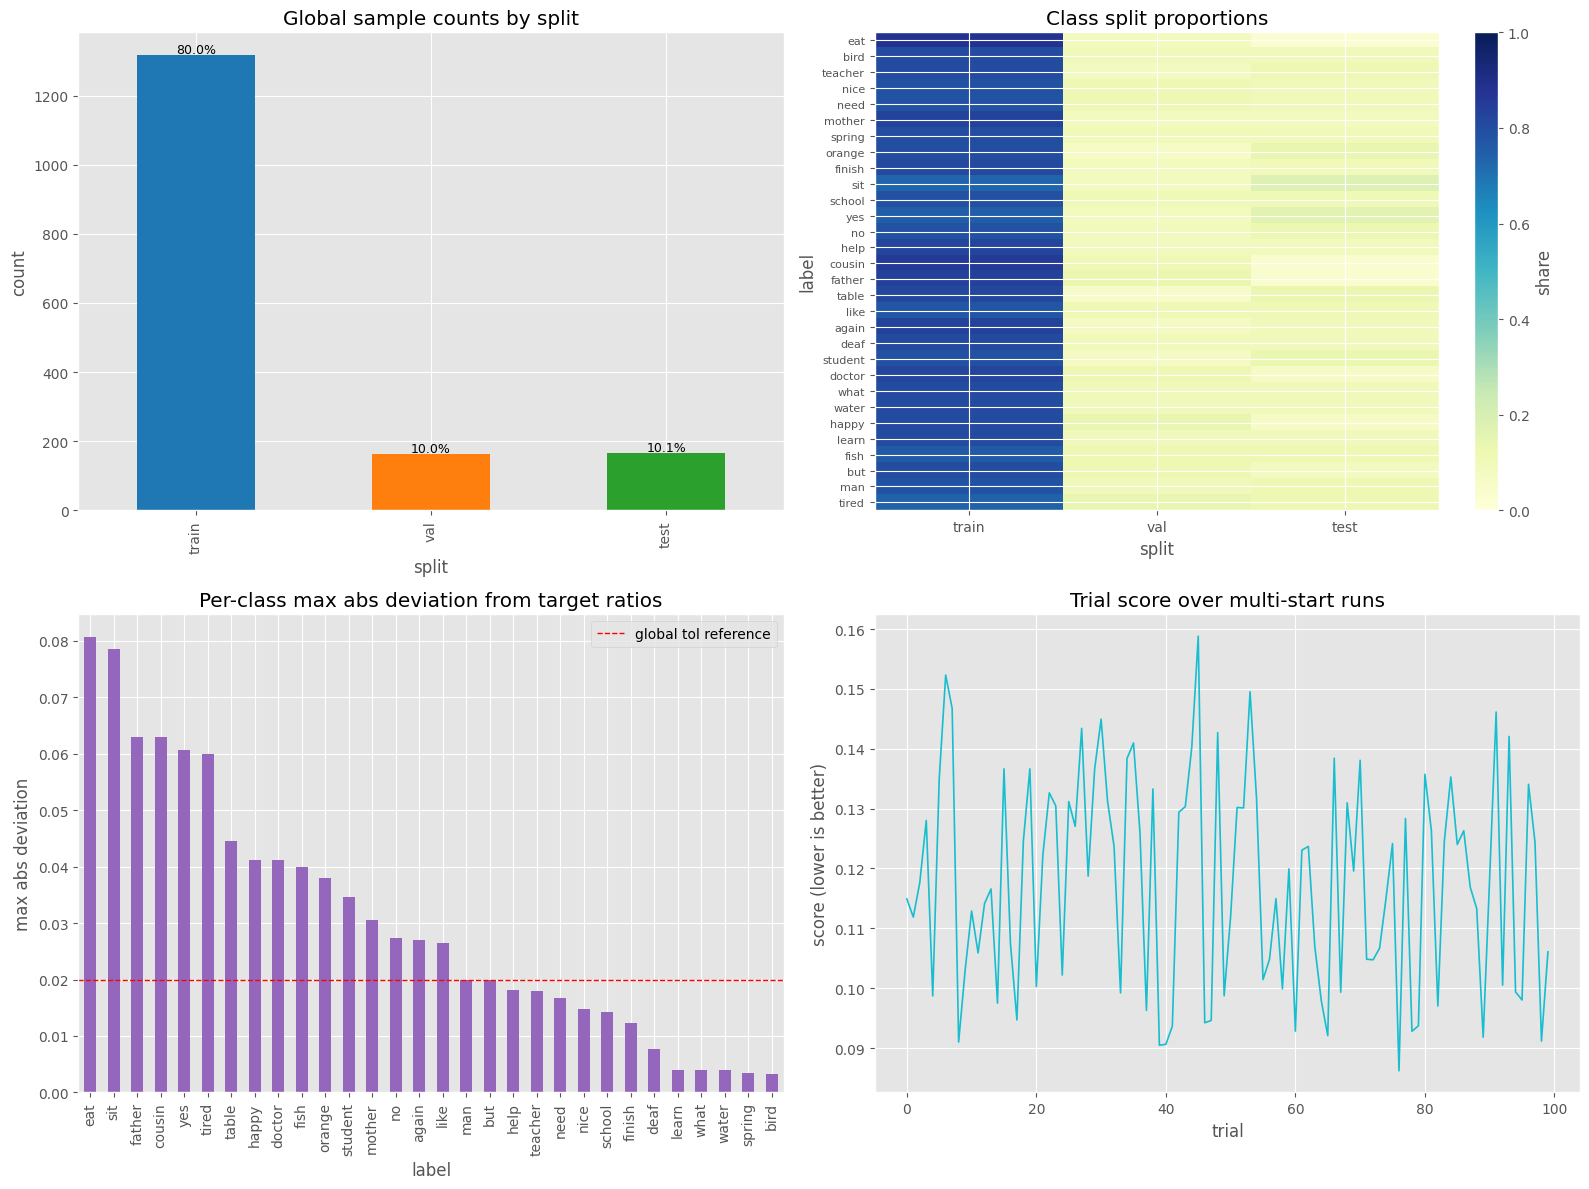

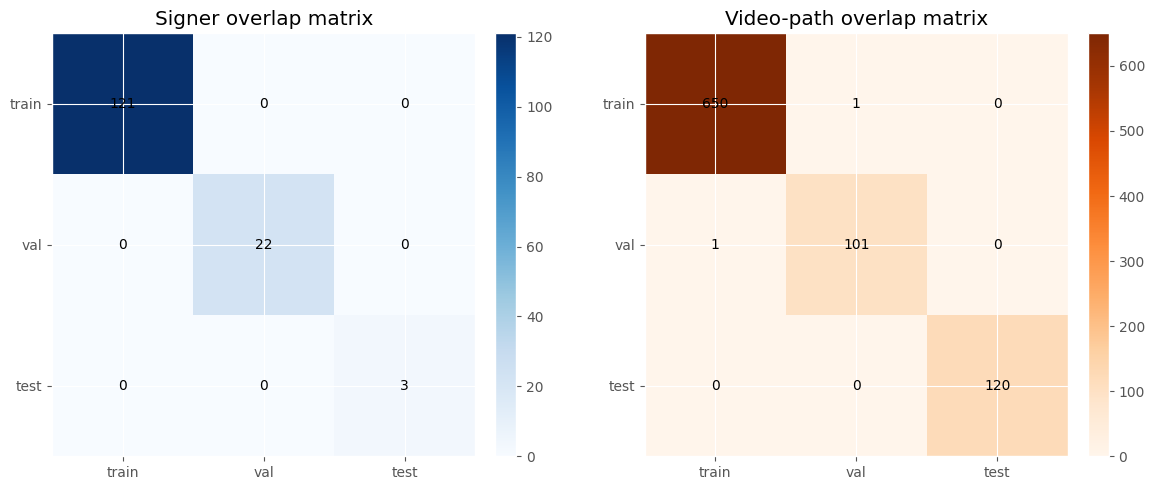

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: global split counts with target percentages
ax = axes[0, 0]
global_counts.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_title('Global sample counts by split')
ax.set_xlabel('split')
ax.set_ylabel('count')
for i, s in enumerate(SPLITS):
    ratio_val = float(global_ratios[s])
    ax.text(i, global_counts[s] + 5, f'{ratio_val * 100:.1f}%', ha='center', fontsize=9)

# Plot 2: class proportions heatmap
ax = axes[0, 1]
class_totals = label_split_counts.sum(axis=1).sort_values(ascending=False)
class_props_sorted = label_split_props.loc[class_totals.index]
mat = class_props_sorted[SPLITS].to_numpy(dtype=float)
im = ax.imshow(mat, aspect='auto', cmap='YlGnBu', vmin=0.0, vmax=1.0)
ax.set_title('Class split proportions')
ax.set_xlabel('split')
ax.set_ylabel(LABEL_COL)
ax.set_xticks(np.arange(len(SPLITS)))
ax.set_xticklabels(SPLITS)
ax.set_yticks(np.arange(len(class_props_sorted.index)))
ax.set_yticklabels(class_props_sorted.index.tolist(), fontsize=8)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('share')

# Plot 3: per-class max abs deviation from target
ax = axes[1, 0]
class_max_dev = label_abs_dev.max(axis=1).sort_values(ascending=False)
class_max_dev.plot(kind='bar', ax=ax, color='#9467bd')
ax.set_title('Per-class max abs deviation from target ratios')
ax.set_xlabel(LABEL_COL)
ax.set_ylabel('max abs deviation')
ax.axhline(GLOBAL_RATIO_TOL, color='red', linestyle='--', linewidth=1, label='global tol reference')
ax.legend(loc='upper right')

# Plot 4: trial objective trajectory
ax = axes[1, 1]
trial_plot = trial_df.sort_values('trial')
ax.plot(trial_plot['trial'], trial_plot['score'], color='#17becf', linewidth=1.2)
ax.set_title('Trial score over multi-start runs')
ax.set_xlabel('trial')
ax.set_ylabel('score (lower is better)')

plt.tight_layout()
plt.show()


def overlap_matrix(df: pd.DataFrame, key_col: str, splits: list[str]) -> np.ndarray:
    sets = {s: set(df.loc[df[SPLIT_COL] == s, key_col].astype(str)) for s in splits}
    mat = np.zeros((len(splits), len(splits)), dtype=int)
    for i, a in enumerate(splits):
        for j, b in enumerate(splits):
            if i == j:
                mat[i, j] = len(sets[a])
            else:
                mat[i, j] = len(sets[a].intersection(sets[b]))
    return mat

signer_overlap = overlap_matrix(split_df, SIGNER_COL, SPLITS)
video_overlap = overlap_matrix(split_df, VIDEO_COL, SPLITS)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes2[0].imshow(signer_overlap, cmap='Blues')
axes2[0].set_title('Signer overlap matrix')
axes2[0].set_xticks(np.arange(len(SPLITS)))
axes2[0].set_yticks(np.arange(len(SPLITS)))
axes2[0].set_xticklabels(SPLITS)
axes2[0].set_yticklabels(SPLITS)
for i in range(len(SPLITS)):
    for j in range(len(SPLITS)):
        axes2[0].text(j, i, str(signer_overlap[i, j]), ha='center', va='center', color='black')
fig2.colorbar(im1, ax=axes2[0], fraction=0.046, pad=0.04)

im2 = axes2[1].imshow(video_overlap, cmap='Oranges')
axes2[1].set_title('Video-path overlap matrix')
axes2[1].set_xticks(np.arange(len(SPLITS)))
axes2[1].set_yticks(np.arange(len(SPLITS)))
axes2[1].set_xticklabels(SPLITS)
axes2[1].set_yticklabels(SPLITS)
for i in range(len(SPLITS)):
    for j in range(len(SPLITS)):
        axes2[1].text(j, i, str(video_overlap[i, j]), ha='center', va='center', color='black')
fig2.colorbar(im2, ax=axes2[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_SPLIT_CSV.parent.mkdir(parents=True, exist_ok=True)

split_df_out = split_df.drop(columns=[GROUP_COL]).copy()
split_df_out.to_csv(OUTPUT_SPLIT_CSV, index=False)

stats_rows = []
for s in SPLITS:
    stats_rows.append({
        'split': s,
        'n_rows': int(global_counts[s]),
        'pct_rows': float(global_ratios[s] * 100.0),
        'target_pct': float(TARGET_SER[s] * 100.0),
        'abs_dev_pct': float(global_abs_dev[s] * 100.0),
        'n_labels_present': int(coverage_per_split[s]),
    })

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(OUTPUT_STATS_CSV, index=False)

signer_map_df = split_df[[SIGNER_COL, GROUP_COL, SPLIT_COL]].drop_duplicates().sort_values([SPLIT_COL, SIGNER_COL]).reset_index(drop=True)
signer_map_df.to_csv(OUTPUT_SIGNER_MAP_CSV, index=False)

label_split_counts.reset_index().to_csv(OUTPUT_LABEL_COUNTS_CSV, index=False)

if len(video_leak_examples) > 0:
    video_leak_examples.to_csv(OUTPUT_VIDEO_LEAK_CSV, index=False)

print('Saved split CSV:', OUTPUT_SPLIT_CSV)
print('Saved stats CSV:', OUTPUT_STATS_CSV)
print('Saved signer map CSV:', OUTPUT_SIGNER_MAP_CSV)
print('Saved label counts CSV:', OUTPUT_LABEL_COUNTS_CSV)
if len(video_leak_examples) > 0:
    print('Saved video leakage examples CSV:', OUTPUT_VIDEO_LEAK_CSV)
else:
    print('No video-path leakage examples to save (count == 0).')

display(stats_df)
display(label_split_counts.head(10))

Saved split CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\split8c_frames_signer_disjoint.csv
Saved stats CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\split8c_frames_stats.csv
Saved signer map CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\split8c_signer_map.csv
Saved label counts CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\split8c_label_split_counts.csv
Saved video leakage examples CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\split8c_video_leak_examples.csv


,split,n_rows,pct_rows,target_pct,abs_dev_pct,n_labels_present
0,train,1317,79.963570,80.0,0.036430,30
1,val,164,9.957498,10.0,0.042502,30
2,test,166,10.078931,10.0,0.078931,30


split,train,val,test
label,,,
again,43,4,5
bird,49,6,6
but,40,6,4
cousin,46,6,2
deaf,42,5,5
doctor,42,6,3
eat,59,6,2
father,45,7,2
finish,46,5,6


: 